# ✈️ Airline Passenger Satisfaction — Mid Project

**Author:** Hisham Mohamed
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · Plotly · SciPy · Streamlit

---

## 1. Introduction

### 1.1 Domain
Airlines compete fiercely on customer experience. Every passenger who leaves dissatisfied is a passenger who may switch to a competitor next time. This project analyses an **airline passenger satisfaction survey**: each row is one passenger, describing *who* they are (gender, age, loyalty), *how* they travelled (travel purpose, cabin class, flight distance, delays) and *how they rated* 14 services of the journey on a 0–5 scale, together with their overall satisfaction.

### 1.2 Dataset description

| Column | Meaning |
|---|---|
| `Unnamed: 0` | Leftover row index from a previous export (no meaning) |
| `id` | Unique passenger identifier |
| `Gender` | Female / Male |
| `Customer Type` | Loyal Customer / disloyal Customer |
| `Age` | Passenger age in years |
| `Type of Travel` | Business travel / Personal Travel |
| `Class` | Cabin class: Business, Eco, Eco Plus |
| `Flight Distance` | Flight distance in miles |
| 14 service columns | Ratings 1–5 of: Inflight wifi, Departure/Arrival time convenience, Ease of online booking, Gate location, Food and drink, Online boarding, Seat comfort, Inflight entertainment, On-board service, Leg room, Baggage handling, Check-in service, Inflight service, Cleanliness — **0 means "Not Applicable"** |
| `Departure Delay in Minutes` | Minutes the departure was delayed |
| `Arrival Delay in Minutes` | Minutes the arrival was delayed |
| `satisfaction` | Target: *satisfied* or *neutral or dissatisfied* |

### 1.3 Research questions
1. **Q1 – Overall:** What share of passengers are satisfied?
2. **Q2 – Who:** How does satisfaction differ across passenger segments (Gender, Customer Type, Type of Travel, Class, Age group)?
3. **Q3 – What:** Which services have the strongest relationship with satisfaction, and where are the biggest rating gaps?
4. **Q4 – Delays:** Do departure and arrival delays reduce satisfaction?
5. **Q5 – Distance:** Does flight distance affect satisfaction, and does the effect depend on cabin class?
6. **Q6 – Combined:** Which combination of travel type and class produces the happiest and the unhappiest passengers?

## 2. Setup — importing libraries

In [1]:
# Core data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Statistics
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

# Consistent, readable plot style for the whole notebook
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)

# Fixed colours: the same category always gets the same colour
SATISFIED_COLOR = "#2a78d6"      # blue
DISSATISFIED_COLOR = "#eb6834"   # orange
SATISFACTION_PALETTE = {"Satisfied": SATISFIED_COLOR, "Neutral or Dissatisfied": DISSATISFIED_COLOR}
CATEGORY_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

DATA_PATH = "Data.csv"
CLEAN_DATA_PATH = "Data_Cleaned.csv"
print("Libraries loaded successfully ✔")

Libraries loaded successfully ✔


## 3. Data Gathering

The data is stored in a CSV file (`Data.csv`). We load it with pandas and take a first look.

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print(f"Rows: {raw_df.shape[0]:,} | Columns: {raw_df.shape[1]}")
raw_df.head()

Rows: 25,976 | Columns: 25


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,3,4,3,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.0,satisfied


## 4. Data Assessment

Before cleaning, we assess the data for **quality** issues (missing, invalid, inconsistent, duplicated values, wrong types) and **tidiness** issues (useless columns, unclear names).

In [3]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  str    
 3   Customer Type                      25976 non-null  str    
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  str    
 6   Class                              25976 non-null  str    
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int64  
 12  F

In [4]:
def quality_report(df):
    """Return a per-column quality summary: dtype, missing values, unique values and a sample value."""
    report = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(),
        "sample": df.iloc[0],
    })
    return report

quality_report(raw_df)

,dtype,missing,missing_%,unique,sample
Unnamed: 0,int64,0,0.00,25976,0
id,int64,0,0.00,25976,19556
Gender,str,0,0.00,2,Female
Customer Type,str,0,0.00,2,Loyal Customer
Age,int64,0,0.00,75,52
Type of Travel,str,0,0.00,2,Business travel
Class,str,0,0.00,3,Eco
Flight Distance,int64,0,0.00,3281,160
Inflight wifi service,int64,0,0.00,6,5
Departure/Arrival time convenient,int64,0,0.00,6,4


### 4.1 Duplicates

In [5]:
print("Fully duplicated rows        :", raw_df.duplicated().sum())
print("Duplicated passenger ids     :", raw_df["id"].duplicated().sum())
print("Is 'Unnamed: 0' just 0..n-1? :", raw_df["Unnamed: 0"].equals(pd.Series(range(len(raw_df)))))

Fully duplicated rows        : 0
Duplicated passenger ids     : 0
Is 'Unnamed: 0' just 0..n-1? : True


### 4.2 Categorical columns — consistency of labels

In [6]:
categorical_columns = ["Gender", "Customer Type", "Type of Travel", "Class", "satisfaction"]
for column in categorical_columns:
    print(f"{column}: {raw_df[column].value_counts().to_dict()}")

Gender: {'Female': 13172, 'Male': 12804}
Customer Type: {'Loyal Customer': 21177, 'disloyal Customer': 4799}
Type of Travel: {'Business travel': 18038, 'Personal Travel': 7938}
Class: {'Business': 12495, 'Eco': 11564, 'Eco Plus': 1917}
satisfaction: {'neutral or dissatisfied': 14573, 'satisfied': 11403}


### 4.3 Numerical columns — ranges and invalid values

In [7]:
raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,25976.0,12987.500000,7498.769632,0.0,6493.75,12987.5,19481.25,25975.0
id,25976.0,65005.657992,37611.526647,17.0,32170.50,65319.5,97584.25,129877.0
Age,25976.0,39.620958,15.135685,7.0,27.00,40.0,51.00,85.0
Flight Distance,25976.0,1193.788459,998.683999,31.0,414.00,849.0,1744.00,4983.0
Inflight wifi service,25976.0,2.724746,1.335384,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,25976.0,3.046812,1.533371,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,25976.0,2.756775,1.412951,0.0,2.00,3.0,4.00,5.0
Gate location,25976.0,2.977094,1.282133,1.0,2.00,3.0,4.00,5.0
Food and drink,25976.0,3.215353,1.331506,0.0,2.00,3.0,4.00,5.0
Online boarding,25976.0,3.261665,1.355536,0.0,2.00,4.0,4.00,5.0


In [8]:
# The 14 rating columns sit between 'Flight Distance' and 'Departure Delay in Minutes'
service_columns = list(raw_df.loc[:, "Inflight wifi service":"Cleanliness"].columns)

# A rating of 0 is outside the 1-5 scale: in this survey it means "Not Applicable"
zero_ratings = (raw_df[service_columns] == 0).sum().sort_values(ascending=False)
print("Number of '0 = Not Applicable' ratings per service:")
zero_ratings[zero_ratings > 0]

Number of '0 = Not Applicable' ratings per service:


Departure/Arrival time convenient    1381
Ease of Online booking               1195
Inflight wifi service                 813
Online boarding                       652
Leg room service                      126
Food and drink                         25
Inflight entertainment                  4
Inflight service                        2
On-board service                        2
Cleanliness                             2
dtype: int64

### 4.4 Outliers in continuous columns

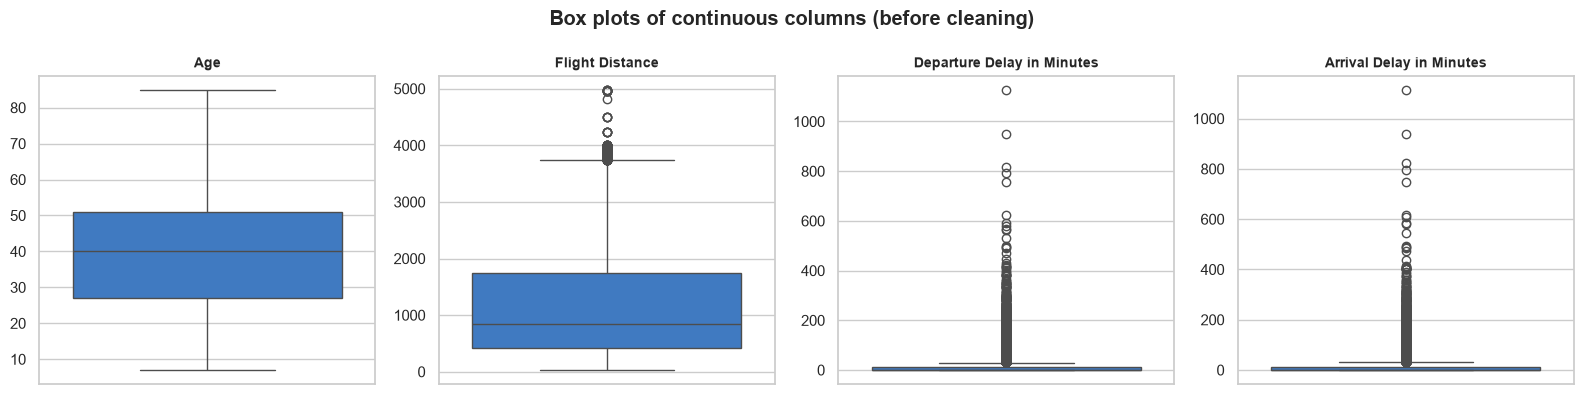

In [9]:
continuous_columns = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for axis, column in zip(axes, continuous_columns):
    sns.boxplot(y=raw_df[column], ax=axis, color=SATISFIED_COLOR, linewidth=1)
    axis.set_title(column, fontsize=10)
    axis.set_ylabel("")
fig.suptitle("Box plots of continuous columns (before cleaning)", fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
def count_iqr_outliers(series):
    """Count values lying outside 1.5 * IQR of a numeric series."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum())

pd.Series({column: count_iqr_outliers(raw_df[column].dropna()) for column in continuous_columns},
          name="IQR outliers")

Age                              0
Flight Distance                584
Departure Delay in Minutes    3569
Arrival Delay in Minutes      3538
Name: IQR outliers, dtype: int64

In [11]:
# Are the delay outliers real? Departure and arrival delays should move together
delay_corr = raw_df["Departure Delay in Minutes"].corr(raw_df["Arrival Delay in Minutes"])
print(f"Correlation between departure and arrival delay: {delay_corr:.3f}")

Correlation between departure and arrival delay: 0.965


### 4.5 Assessment summary — problems found in the data

**Quality issues**
1. `Arrival Delay in Minutes` has **83 missing values** (0.32 %).
2. `Arrival Delay in Minutes` is stored as **float** although it holds whole minutes.
3. Service ratings contain **0 values that are not real ratings** (0 = "Not Applicable"), e.g. 1,381 in *Departure/Arrival time convenient* and 1,195 in *Ease of Online booking*. Left as 0 they would wrongly drag the averages down.
4. **Inconsistent capitalisation** in labels: `disloyal Customer` vs `Loyal Customer`, `Business travel` vs `Personal Travel`, `neutral or dissatisfied` / `satisfied` in lower case, `Eco` as an abbreviation of *Economy*.
5. **Extreme outliers** in delays (max ≈ 1,128 minutes) and flight distance. The very strong correlation between departure and arrival delays (≈ 0.96) shows they are *genuine* long delays, not typing errors — so they are kept, but capped where needed in plots.
6. Categorical columns are stored as plain text instead of the memory-efficient **category** type.

**Tidiness issues**
7. `Unnamed: 0` is a **useless index column** left over from a previous export.
8. Column names contain **spaces, slashes and mixed case** (e.g. `Departure/Arrival time convenient`), which are awkward to use in code.
9. There is no **age group** or **delay category** column to compare passenger segments easily.

No duplicated rows or duplicated passenger ids were found.